# First attempt at a mother py script


# Imports

### Allowed ones

In [1]:
import numpy as np
import pandas as pd

### Ones from our files

In [2]:
from data_to_image import Image

### For library implementations, exploratory analysis or visualisations

In [3]:
import matplotlib.pyplot as plt

import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA

# Data Load
### Currently commented out the test data as we don't need to use this yet

In [7]:
test_data_filepath = 'fashion_test.npy'
train_data_filepath = 'fashion_train.npy'
fashion_train = np.load(train_data_filepath)
fashion_test = np.load(test_data_filepath)

# Plot some images with their given class

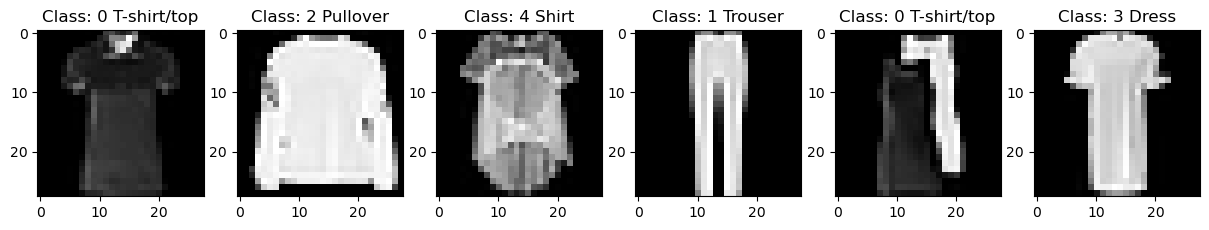

In [8]:
image_choices = [100, 4511, 200, 300, 444, 500]

image_shape = (28,28)

fig, axs = plt.subplots(1, len(image_choices), figsize=(15, 3))

n = 0

for index_choice in image_choices:
        
    this_image = Image(fashion_train, index_choice)

    axs[n].imshow(this_image.image.reshape(image_shape), cmap='gray')
    axs[n].set_title(f"{this_image._tell_class()}")

    n +=1

# Seperate just the category data (the 'Y' parts)

In [9]:
all_the_classes = []

for array in fashion_train:
    all_the_classes.append(array[-1])

array_the_classes = np.array(all_the_classes)

# Report class counts and plot the counts

Counter({0: 2033, 4: 2014, 3: 2005, 2: 2001, 1: 1947})


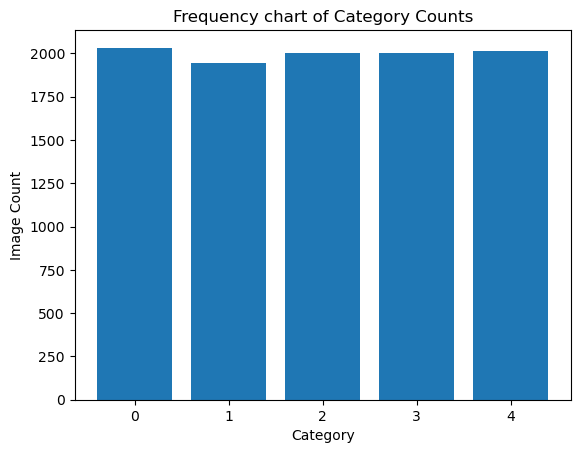

In [10]:
class_counts = Counter(array_the_classes)
print(class_counts)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Category")
plt.ylabel("Image Count")
plt.title("Frequency chart of Category Counts")
plt.show()



# Create an array of just the image data (the 'X' part of the data)

In [11]:
all_the_images = []

for array in fashion_train:
    all_the_images.append(array[:-1])

array_the_images = np.array(all_the_images)

# Split the data into training and validation

In [12]:
X_train_initial, X_validate_initial, Y_train_initial, Y_validate_initial = train_test_split(array_the_images, array_the_classes , test_size = 0.2, random_state = 43, stratify = array_the_classes) #I'm hoping that the stratify parameter keeps the balance of classes in the two splits

a=len(X_train_initial)
b=len(X_validate_initial)

print(f'Train size {a} Validate size {b}')

Train size 8000 Validate size 2000


# Perform the PCA

In [13]:
pca = PCA()

# With sklearn PCA, it automatically centers the data
pca.fit(X_train_initial)

# Eigenvalues, PC scores and variance explained
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
explained_variance_ratio = pca.explained_variance_ratio_ * 100
scores = pca.transform(X_train_initial)

# Plot the cumulative explained variance

[Text(0.5, 0, 'Principal Component by Importance'),
 Text(0, 0.5, 'Cumulative Variance Ratio'),
 Text(0.5, 1.0, 'Cumulative Explained Variance')]

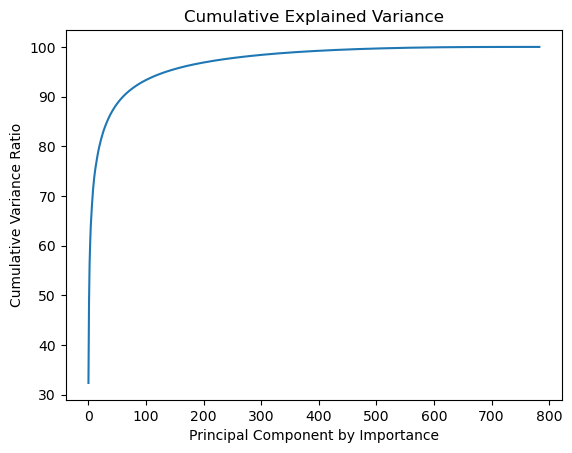

In [14]:
CEV = sns.lineplot(x=range(0, len(eigenvectors)), y=np.cumsum(explained_variance_ratio))
CEV.set(xlabel = 'Principal Component by Importance', ylabel = 'Cumulative Variance Ratio', title = 'Cumulative Explained Variance')

# How many principal components do we use?

In [15]:
def number_of_components(variance_threshold, explained_variance_ratio = explained_variance_ratio, eigenvalues = eigenvalues):

    ''' Enter a % variance threshold to be told how many prinicpal components should be included in analysis'''
    
    cum_explained_variance = 0
    no_of_components = 0
    array_of_features = []

    while cum_explained_variance <= variance_threshold:
        cum_explained_variance += explained_variance_ratio[no_of_components]
        no_of_components +=1

    for component in range(no_of_components):
        array_of_features.append(eigenvalues[component])

    return len(array_of_features)

In [16]:
#70% threshold
number_of_components(70)

9

In [17]:
#90% Threshold
number_of_components(90)

62

In [23]:
#90% Threshold
number_of_components(95)

136

### Knowing how many components we need, we'll perform the PCA again, this time only retaining the number of components (features) we need

In [20]:
#First for the 70% threshold - MAKE SURE to change to 90% for the final run
pca_with_threshold = PCA(n_components = number_of_components(90))

#then transform all the images using only the components that combine to make the threshold
#essnetially this means for us the image will look a bit blurred, but it should still be defniable into the correct class
transformed_images = pca_with_threshold.fit_transform(array_the_images)

# Redo the train/test split, now that the images have been transformed by the pca that took information from the training data
## Same random state should keep the original split

In [21]:
X_train, X_validate, Y_train, Y_validate = train_test_split(transformed_images, array_the_classes , test_size = 0.2, random_state = 43, stratify = array_the_classes)


# Export post PCA/Transformed data

In [17]:
np.save('..\\post_pca_data\\X_train', X_train)
np.save('..\\post_pca_data\\X_validate', X_validate)
np.save('..\\post_pca_data\\Y_train', Y_train)
np.save('..\\post_pca_data\\Y_validate', Y_validate)

# Also export pre-PCA data for the FFNN

In [18]:
np.save('..\\post_pca_data\\X_train_initial', X_train_initial)
np.save('..\\post_pca_data\\X_validate_initial', X_validate_initial)
np.save('..\\post_pca_data\\Y_train_initial', Y_train_initial)
np.save('..\\post_pca_data\\Y_validate_initial', Y_validate_initial)

# Next file to follow is M1_M2
